In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

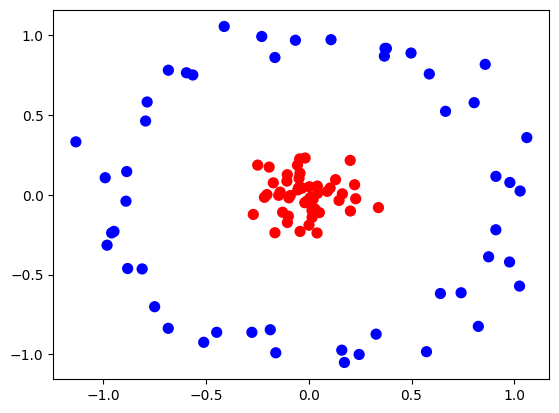

In [19]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

X, y = make_circles(100, factor=0.1, noise=0.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')
plt.show()

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

## Using Linear Kernel

In [21]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.5

In [23]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1,
                                 stop = X_set[:, 0].max() + 1,
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1,
                                 stop = X_set[:, 1].max() + 1,
                                 step = 0.01))

    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(),
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75,
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

/tmp/ipython-input-3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


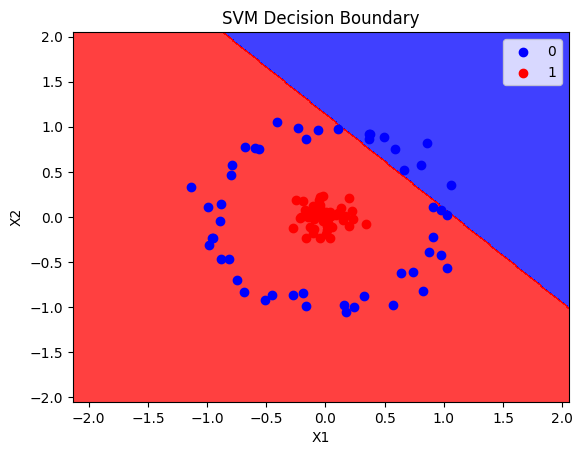

In [24]:
plot_decision_boundary(X, y, classifier)

In [25]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

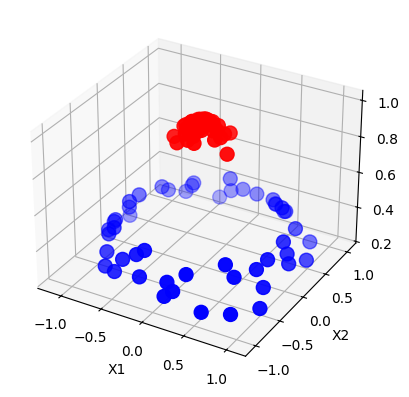

In [26]:
plot_3d_plot(X,y)

## Using rbf Kernel

In [27]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [28]:
accuracy_score(y_test, y_pred)

1.0

/tmp/ipython-input-3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


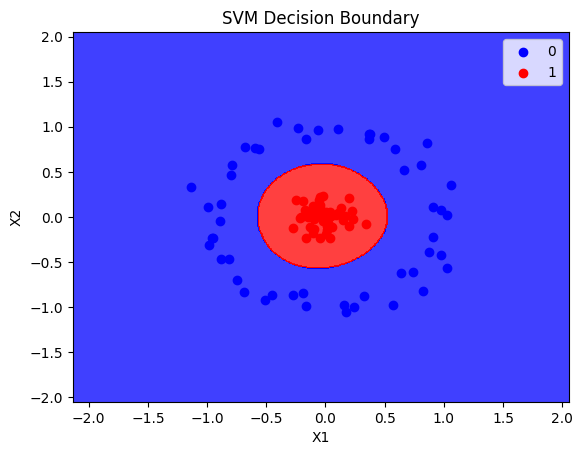

In [29]:
plot_decision_boundary(X, y, rbf_classifier)

## Using Polynomial Kernel

In [30]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [31]:
accuracy_score(y_test, y_pred)

1.0

/tmp/ipython-input-3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


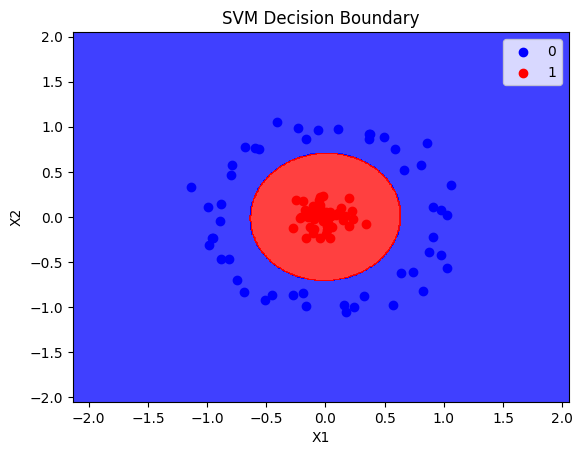

In [32]:
plot_decision_boundary(X, y, poly_classifier)

In [33]:
X

array([[-5.11341687e-01, -9.24050040e-01],
       [ 9.77302708e-01, -4.21211502e-01],
       [ 1.59820229e-02, -1.42169676e-01],
       [-9.90870673e-01,  1.06541251e-01],
       [ 1.03862896e-01,  4.21295099e-02],
       [-9.66776265e-02, -1.92481949e-02],
       [ 2.23017328e-01,  6.25785891e-02],
       [ 7.41406223e-01, -6.13877562e-01],
       [-4.23854988e-02, -2.29722996e-01],
       [-1.64809532e-01,  8.59404816e-01],
       [-2.48683925e-01,  1.85533608e-01],
       [ 4.33069248e-02,  1.00368028e-02],
       [-2.76902984e-01, -8.61611685e-01],
       [ 9.10667916e-01, -2.19377238e-01],
       [ 5.86602667e-01,  7.56325206e-01],
       [ 1.30414759e-01,  9.46155443e-02],
       [-4.28931835e-02,  1.35101290e-01],
       [ 3.01064962e-02, -8.97370494e-02],
       [ 3.27833455e-01, -8.73011351e-01],
       [-8.89789839e-01, -4.03376559e-02],
       [-5.34661813e-02,  3.03042935e-02],
       [ 2.01690784e-01,  2.14982191e-01],
       [ 9.10842449e-01,  1.15051585e-01],
       [ 1.

In [34]:
np.exp(-(X**2)).sum(1)

array([1.19568341, 1.22219447, 1.97973529, 1.36334004, 1.98749715,
       1.99032656, 1.94757147, 1.26315457, 1.94680073, 1.4509969 ,
       1.90619281, 1.99802554, 1.40217283, 1.38936097, 1.27323595,
       1.97422366, 1.98007507, 1.99107361, 1.36476175, 1.45143635,
       1.99622752, 1.91497153, 1.42305928, 1.96429668, 1.17356453,
       1.43510557, 0.99168761, 1.10068568, 1.35565682, 1.17101814,
       1.99712369, 1.06998634, 1.24024987, 1.25944299, 1.99026077,
       1.98490882, 1.29888176, 1.34015647, 1.4547832 , 1.99965905,
       1.99150214, 1.23556212, 1.99838892, 1.32349811, 1.01299371,
       1.3440364 , 1.95943897, 1.38812038, 1.99532401, 1.26738313,
       1.99188677, 1.9814724 , 1.97236885, 1.98055612, 1.18112154,
       1.91453483, 1.8849737 , 1.97348316, 1.99665894, 1.28642821,
       1.20403515, 1.29413432, 1.36237206, 1.17277643, 1.37783744,
       1.30939435, 1.32383902, 1.30300784, 1.95422392, 1.96505556,
       1.9871466 , 1.94819215, 1.37779303, 1.933964  , 1.99562

In [35]:
X_new=np.exp(-(X**2))

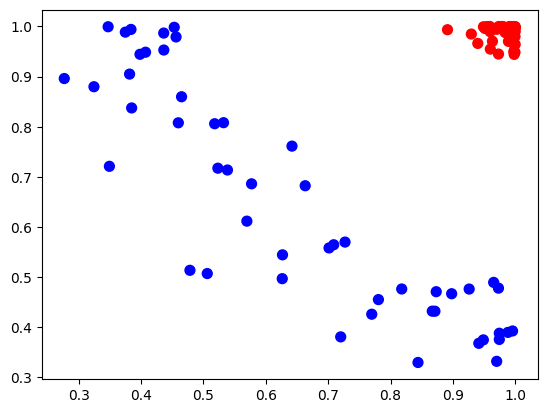

In [36]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')

## Using sigmoid Kernel

In [38]:
sigmoid_classifier = SVC(kernel="sigmoid")
sigmoid_classifier.fit(X_train, y_train)
y_pred = sigmoid_classifier.predict(X_test)

In [39]:
accuracy_score(y_test, y_pred)

0.8

/tmp/ipython-input-3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


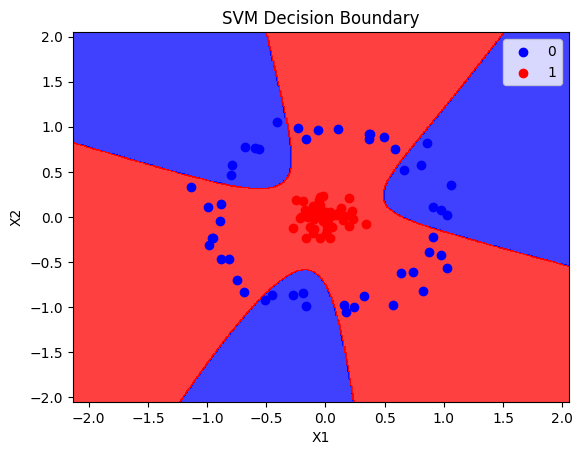

In [40]:
plot_decision_boundary(X, y, sigmoid_classifier)